Barrios urbanos cargados: 271


C:\Users\manuz\AppData\Local\Temp\ipykernel_18704\3986036101.py:17: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(zonas_urbano)


Matriz Queen creada
   Número de barrios: 271
   Número de conexiones (pares de vecinos): 1538.0
   ¿Hay islas (barrios sin vecinos)? False
Matriz estandarizada por filas
   Cada fila suma 1 (los pesos representan la proporción de influencia)
Vecinos del barrio 'U.P.B' (ID: 0):
   1. Bolivariana (peso = 0.17)
   2. Rosales (peso = 0.17)
   3. El Nogal-Los Almendros (peso = 0.17)
   4. San Joaquín (peso = 0.17)
   5. Laureles (peso = 0.17)
   6. Los Conquistadores (peso = 0.17)
Estadísticas de vecindad:
   Promedio de vecinos por barrio: 5.68
   Máximo de vecinos: 12
   Mínimo de vecinos: 2
Distribución del número de vecinos:
2      8
3     16
4     47
5     50
6     65
7     52
8     24
9      5
11     3
12     1
Name: count, dtype: int64


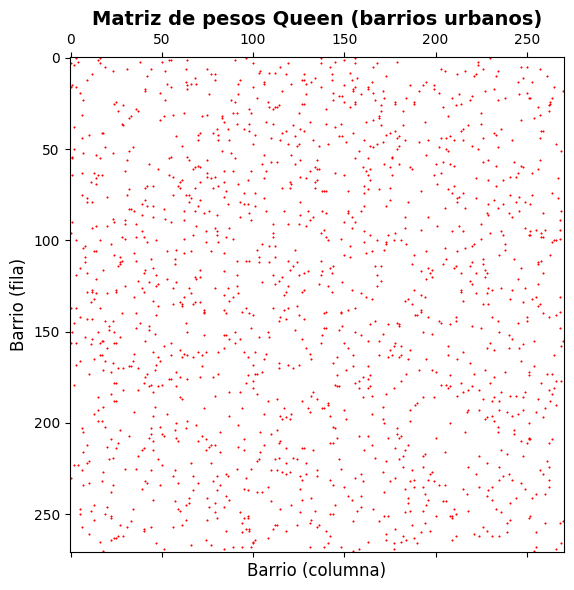

Matriz visualizada y guardada


In [2]:
import geopandas as gpd
from libpysal.weights import Queen
import pandas as pd
import numpy as np
import os

ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Filtrar solo zonas urbanas
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()
print(f"Barrios urbanos cargados: {len(zonas_urbano)}")

# Matriz Queen

# Crear la matriz de pesos Queen (vecinos si comparten borde o vértice)
w_queen = Queen.from_dataframe(zonas_urbano)

print(f"Matriz Queen creada")
print(f"   Número de barrios: {w_queen.n}")
print(f"   Número de conexiones (pares de vecinos): {w_queen.s0}")
print(f"   ¿Hay islas (barrios sin vecinos)? {len(w_queen.islands) > 0}")


w_queen.transform = 'R'

print(f"Matriz estandarizada por filas")
print(f"   Cada fila suma 1 (los pesos representan la proporción de influencia)")


# Ver los vecinos de un barrio específico (ej. el primero)
primer_barrio = zonas_urbano.index[0]
vecinos = w_queen.neighbors[primer_barrio]
pesos = w_queen.weights[primer_barrio]

print(f"Vecinos del barrio '{zonas_urbano.loc[primer_barrio, 'NOMBRE']}' (ID: {primer_barrio}):")
for i, (vecino, peso) in enumerate(zip(vecinos, pesos)):
    nombre_vecino = zonas_urbano.loc[vecino, 'NOMBRE'] if vecino in zonas_urbano.index else f'ID_{vecino}'
    print(f"   {i+1}. {nombre_vecino} (peso = {peso:.2f})")

# Calcular el número de vecinos por barrio
num_vecinos = [len(v) for v in w_queen.neighbors.values()]

print(f"Estadísticas de vecindad:")
print(f"   Promedio de vecinos por barrio: {np.mean(num_vecinos):.2f}")
print(f"   Máximo de vecinos: {max(num_vecinos)}")
print(f"   Mínimo de vecinos: {min(num_vecinos)}")

# Ver cuántos barrios tienen cada número de vecinos
conteo_vecinos = pd.Series(num_vecinos).value_counts().sort_index()
print(f"Distribución del número de vecinos:")
print(conteo_vecinos)

#Ver matriz

import matplotlib.pyplot as plt

# Visualizar la matriz como un gráfico de calor
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.spy(w_queen.sparse, markersize=0.5, color='red')
ax.set_title('Matriz de pesos Queen (barrios urbanos)', fontsize=14, fontweight='bold')
ax.set_xlabel('Barrio (columna)', fontsize=12)
ax.set_ylabel('Barrio (fila)', fontsize=12)
plt.tight_layout()

ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Matriz_Queen_Visualizacion.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"Matriz visualizada y guardada")


Barrios urbanos cargados: 271
Columnas: ['OBJECTID', 'NOMBRE', 'ABREVIATURA', 'SUBTIPO_BARRIOVEREDA', 'SHAPE_Length', 'SHAPE_Area', 'Tipo', 'geometry', 'ID', 'Temp_media']


C:\Users\manuz\AppData\Local\Temp\ipykernel_18704\4184155250.py:28: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(zonas_urbano)


Matriz Queen creada
Numero de barrios: 271
Numero de conexiones: 271.0

INDICE DE MORAN GLOBAL
Moran's I: 0.6826794854081781
Valor esperado (aleatorio): -0.003703703703703704
p-valor (simulado): 0.001
Autocorrelacion espacial POSITIVA y SIGNIFICATIVA
Los barrios con alta temperatura estan cerca de otros barrios calidos


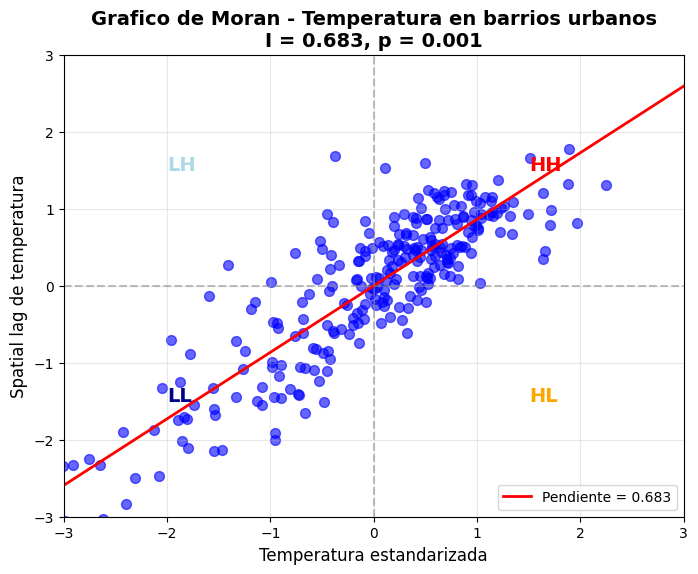

Grafico de Moran guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Moran_Plot_Temperatura_Urbano.png


In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import esda
from libpysal.weights import Queen
import os
from scipy.stats import linregress

ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

ruta_temp = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"
df_temp = pd.read_csv(ruta_temp)

temp_promedio = df_temp.groupby('ID').agg({
    'Temp_media': 'mean'
}).reset_index()

zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print("Barrios urbanos cargados:", len(zonas_urbano))
print("Columnas:", zonas_urbano.columns.tolist())

# Matriz queen

w_queen = Queen.from_dataframe(zonas_urbano)
w_queen.transform = 'R'

print("Matriz Queen creada")
print("Numero de barrios:", w_queen.n)
print("Numero de conexiones:", w_queen.s0)

# 3. CALCULAR EL INDICE DE MORAN

y = zonas_urbano['Temp_media'].values
moran = esda.Moran(y, w_queen)

# Resultados

print("\nINDICE DE MORAN GLOBAL")
print("Moran's I:", moran.I)
print("Valor esperado (aleatorio):", moran.EI)
print("p-valor (simulado):", moran.p_sim)

if moran.p_sim < 0.05:
    if moran.I > 0:
        print("Autocorrelacion espacial POSITIVA y SIGNIFICATIVA")
        print("Los barrios con alta temperatura estan cerca de otros barrios calidos")
    else:
        print("Autocorrelacion espacial NEGATIVA y SIGNIFICATIVA")
else:
    print("No hay evidencia de autocorrelacion espacial significativa")

# Grafico

zonas_urbano['w_Temp'] = w_queen.sparse @ y

fig, ax = plt.subplots(1, figsize=(8, 6))

y_std = (y - y.mean()) / y.std()
w_y_std = (zonas_urbano['w_Temp'] - zonas_urbano['w_Temp'].mean()) / zonas_urbano['w_Temp'].std()

ax.scatter(y_std, w_y_std, alpha=0.6, color='blue', s=50)

slope, intercept, r_value, p_value, std_err = linregress(y_std, w_y_std)
x_line = np.array([-3, 3])
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label='Pendiente = ' + str(round(moran.I, 3)))

ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

ax.text(1.5, 1.5, "HH", fontsize=14, fontweight='bold', color='red')
ax.text(-2, 1.5, "LH", fontsize=14, fontweight='bold', color='lightblue')
ax.text(1.5, -1.5, "HL", fontsize=14, fontweight='bold', color='orange')
ax.text(-2, -1.5, "LL", fontsize=14, fontweight='bold', color='darkblue')

ax.set_xlabel('Temperatura estandarizada', fontsize=12)
ax.set_ylabel('Spatial lag de temperatura', fontsize=12)
ax.set_title('Grafico de Moran - Temperatura en barrios urbanos\nI = ' + str(round(moran.I, 3)) + ', p = ' + str(round(moran.p_sim, 4)), fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Moran_Plot_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Grafico de Moran guardado en:", os.path.join(ruta_resultados, "Moran_Plot_Temperatura_Urbano.png"))

Barrios urbanos cargados: 271


C:\Users\manuz\AppData\Local\Temp\ipykernel_18704\1919474801.py:26: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(zonas_urbano)


Moran's I: 0.6826794854081781
p-valor: 0.001


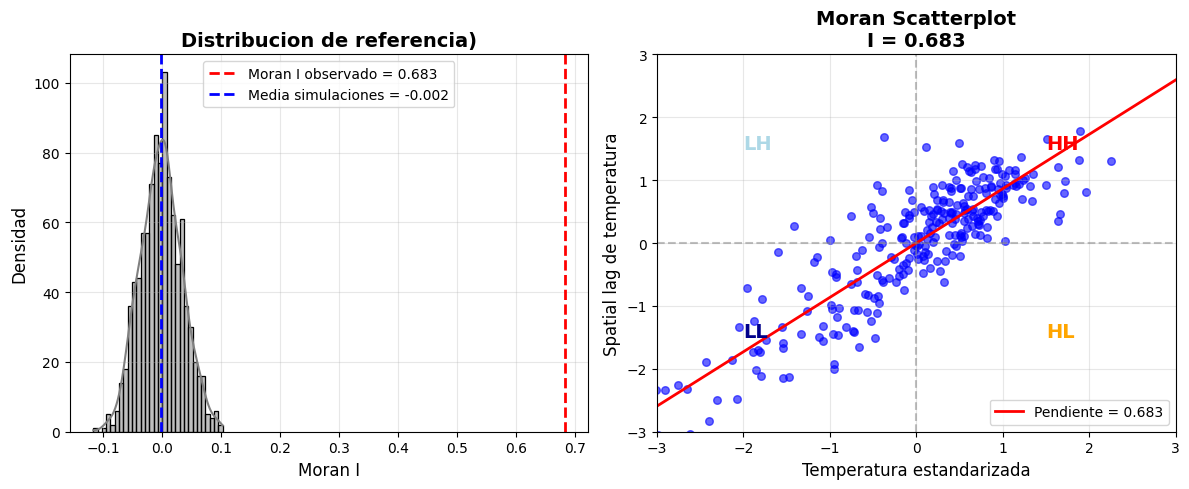

Grafico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Moran_Plot_Con_Distribucion.png


In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import esda
from libpysal.weights import Queen
import os
import seaborn as sns

ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

ruta_temp = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"
df_temp = pd.read_csv(ruta_temp)

temp_promedio = df_temp.groupby('ID').agg({
    'Temp_media': 'mean'
}).reset_index()

zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print("Barrios urbanos cargados:", len(zonas_urbano))


w_queen = Queen.from_dataframe(zonas_urbano)
w_queen.transform = 'R'


y = zonas_urbano['Temp_media'].values
moran = esda.Moran(y, w_queen, permutations=999)

print("Moran's I:", moran.I)
print("p-valor:", moran.p_sim)

#Grafico

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: Distribucion de referencia (histograma de simulaciones)
sns.histplot(moran.sim, bins=30, kde=True, color='gray', ax=axes[0])
axes[0].axvline(moran.I, color='red', linestyle='--', linewidth=2, label='Moran I observado = ' + str(round(moran.I, 3)))
axes[0].axvline(np.mean(moran.sim), color='blue', linestyle='--', linewidth=2, label='Media simulaciones = ' + str(round(np.mean(moran.sim), 3)))
axes[0].set_xlabel('Moran I', fontsize=12)
axes[0].set_ylabel('Densidad', fontsize=12)
axes[0].set_title('Distribucion de referencia)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel derecho: Scatter plot de Moran
# Calcular spatial lag
zonas_urbano['w_Temp'] = w_queen.sparse @ y

# Estandarizar variables
y_std = (y - y.mean()) / y.std()
w_y_std = (zonas_urbano['w_Temp'] - zonas_urbano['w_Temp'].mean()) / zonas_urbano['w_Temp'].std()

# Scatter plot
axes[1].scatter(y_std, w_y_std, alpha=0.6, color='blue', s=30)

# Linea de regresion (pendiente = Moran's I)
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(y_std, w_y_std)
x_line = np.array([-3, 3])
axes[1].plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label='Pendiente = ' + str(round(moran.I, 3)))

# Lineas de referencia
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Etiquetas de cuadrantes
axes[1].text(1.5, 1.5, "HH", fontsize=14, fontweight='bold', color='red')
axes[1].text(-2, 1.5, "LH", fontsize=14, fontweight='bold', color='lightblue')
axes[1].text(1.5, -1.5, "HL", fontsize=14, fontweight='bold', color='orange')
axes[1].text(-2, -1.5, "LL", fontsize=14, fontweight='bold', color='darkblue')

axes[1].set_xlabel('Temperatura estandarizada', fontsize=12)
axes[1].set_ylabel('Spatial lag de temperatura', fontsize=12)
axes[1].set_title('Moran Scatterplot\nI = ' + str(round(moran.I, 3)), fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)

plt.tight_layout()

ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Moran_Plot_Con_Distribucion.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Grafico guardado en:", os.path.join(ruta_resultados, "Moran_Plot_Con_Distribucion.png"))

Zonas cargadas: 332
Urbanas: 271
Rurales: 61


C:\Users\manuz\AppData\Local\Temp\ipykernel_18704\3920159616.py:32: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(zonas_todas)


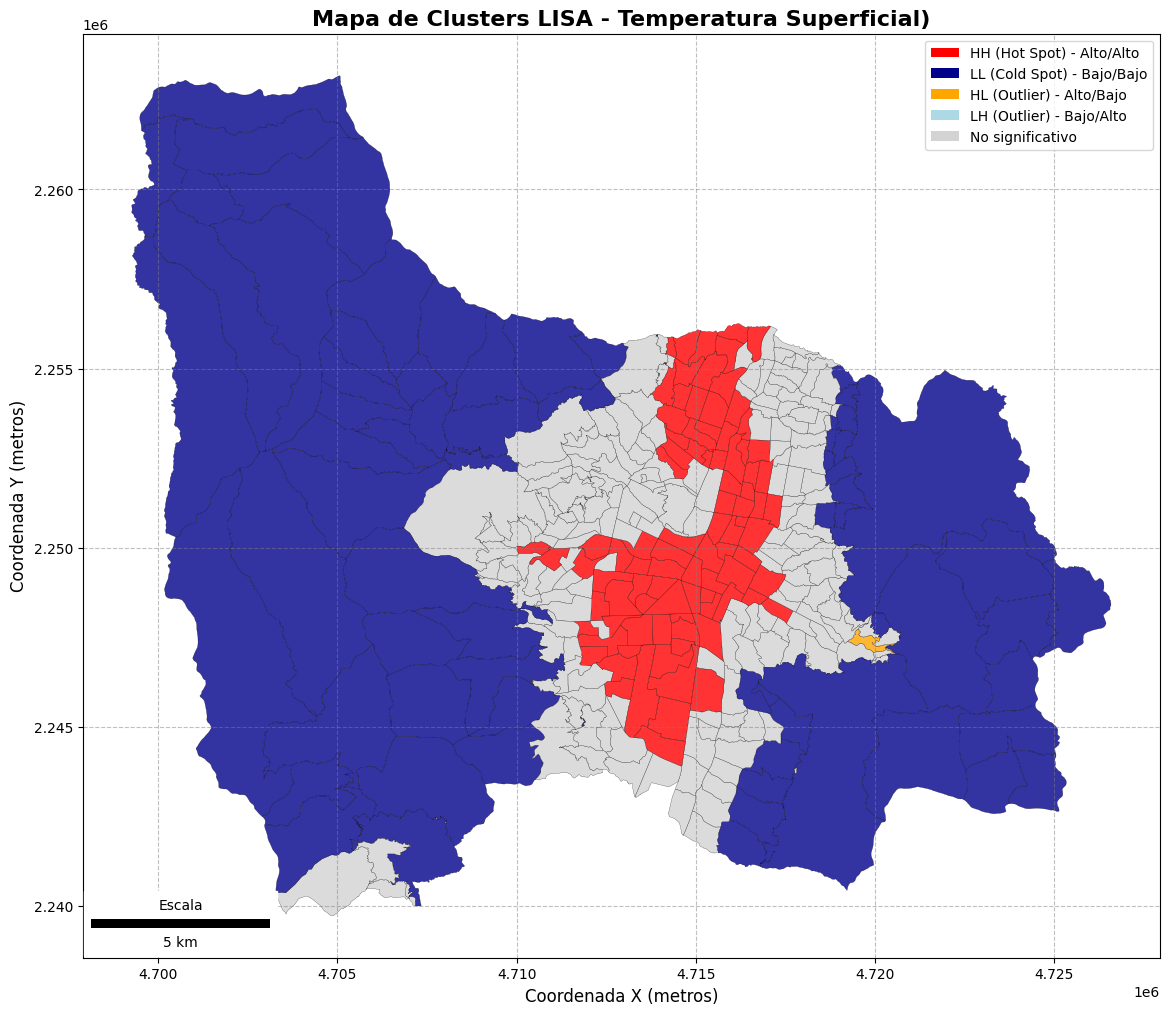

Mapa LISA guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\LISA_Map_Temperatura_Urbano_Rural.png
Todas las zonas:
Clusters significativos (p < 0.05): 159
HH (Hot spots): 89
LL (Cold spots): 69
HL (Outliers): 1
LH (Outliers): 0

----------------------------------------
Por tipo de zona:

Urbano:
  Zonas totales: 271
  Zonas significativas: 109
  HH (Hot spots): 89
  LL (Cold spots): 19
  HL (Outliers): 1
  LH (Outliers): 0

Rural:
  Zonas totales: 61
  Zonas significativas: 50
  HH (Hot spots): 0
  LL (Cold spots): 50
  HL (Outliers): 0
  LH (Outliers): 0


In [8]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import esda
from libpysal.weights import Queen
import os
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch


ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

ruta_temp = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"
df_temp = pd.read_csv(ruta_temp)

temp_promedio = df_temp.groupby('ID').agg({
    'Temp_media': 'mean'
}).reset_index()

zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')

zonas_todas = zonas_temp.copy()

print("Zonas cargadas:", len(zonas_todas))
print("Urbanas:", len(zonas_todas[zonas_todas['Tipo'] == 'Urbano']))
print("Rurales:", len(zonas_todas[zonas_todas['Tipo'] == 'Rural']))

# Matriz QUEEN

w_queen = Queen.from_dataframe(zonas_todas)
w_queen.transform = 'R'

# LISA

y = zonas_todas['Temp_media'].values
lisa = esda.Moran_Local(y, w_queen)


zonas_todas['cuadrante'] = lisa.q
zonas_todas['p_valor'] = lisa.p_sim
zonas_todas['significativo'] = lisa.p_sim < 0.05

# Mapa

fig, ax = plt.subplots(1, figsize=(14, 12))

# Definir colores para cada cuadrante
colores = {
    1: 'red',       # HH (Alto-Alto) - Hot spot
    2: 'lightblue', # LH (Bajo-Alto) - Outlier
    3: 'darkblue',  # LL (Bajo-Bajo) - Cold spot
    4: 'orange'     # HL (Alto-Bajo) - Outlier
}

# Asignar color a cada zona
zonas_todas['color'] = zonas_todas.apply(
    lambda row: colores[row['cuadrante']] if row['significativo'] else 'lightgray',
    axis=1
)

# Graficar el mapa
zonas_todas.plot(
    ax=ax,
    color=zonas_todas['color'],
    edgecolor='black',
    linewidth=0.2,
    alpha=0.8
)

# Configurar titulo
ax.set_title('Mapa de Clusters LISA - Temperatura Superficial)', 
             fontsize=16, fontweight='bold')


ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

# 
scalebar = ScaleBar(
    dx=1, 
    units="m", 
    dimension="si-length",
    label="Escala",
    location='lower left',
    frameon=True,
    pad=0.5,
    font_properties={'size': 10}
)
ax.add_artist(scalebar)

# 
legend_elements = [
    Patch(facecolor='red', label='HH (Hot Spot) - Alto/Alto'),
    Patch(facecolor='darkblue', label='LL (Cold Spot) - Bajo/Bajo'),
    Patch(facecolor='orange', label='HL (Outlier) - Alto/Bajo'),
    Patch(facecolor='lightblue', label='LH (Outlier) - Bajo/Alto'),
    Patch(facecolor='lightgray', label='No significativo')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# 
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "LISA_Map_Temperatura_Urbano_Rural.png"), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Mapa LISA guardado en:", os.path.join(ruta_resultados, "LISA_Map_Temperatura_Urbano_Rural.png"))

print("Todas las zonas:")
print("Clusters significativos (p < 0.05):", zonas_todas['significativo'].sum())

n_hh = zonas_todas[(zonas_todas['significativo']) & (zonas_todas['cuadrante'] == 1)].shape[0]
n_ll = zonas_todas[(zonas_todas['significativo']) & (zonas_todas['cuadrante'] == 3)].shape[0]
n_hl = zonas_todas[(zonas_todas['significativo']) & (zonas_todas['cuadrante'] == 4)].shape[0]
n_lh = zonas_todas[(zonas_todas['significativo']) & (zonas_todas['cuadrante'] == 2)].shape[0]

print("HH (Hot spots):", n_hh)
print("LL (Cold spots):", n_ll)
print("HL (Outliers):", n_hl)
print("LH (Outliers):", n_lh)

print("\n" + "-" * 40)
print("Por tipo de zona:")

for tipo in ['Urbano', 'Rural']:
    subset = zonas_todas[zonas_todas['Tipo'] == tipo]
    sig = subset[subset['significativo']]
    
    print("\n" + tipo + ":")
    print("  Zonas totales:", len(subset))
    print("  Zonas significativas:", len(sig))
    print("  HH (Hot spots):", sig[sig['cuadrante'] == 1].shape[0])
    print("  LL (Cold spots):", sig[sig['cuadrante'] == 3].shape[0])
    print("  HL (Outliers):", sig[sig['cuadrante'] == 4].shape[0])
    print("  LH (Outliers):", sig[sig['cuadrante'] == 2].shape[0])